# League Analysis

In [58]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

model_aliases = {
    "fixed_2p": "DQN Fixed",
    "fixed_3p": "DQN Fixed",
    "fixed_4p": "DQN Fixed",
    "variable_2_4": "DQN Variable",
    "variable_encoder_2_4": "DQN Variable + Encoder",
    "random": "Random",
}
model_order = ["DQN Fixed", "DQN Variable", "DQN Variable + Encoder", "Random"]

result_roots = [Path("results/league_results"), Path("../../results/league_results")]
results_root = next(path for path in result_roots if path.exists())

frames = []
for player_count in (2, 3, 4):
    path = results_root / f"{player_count}p" / "matches.csv"
    if not path.exists():
        continue
    data = pd.read_csv(path)
    data["player_count"] = player_count
    frames.append(data)

df = pd.concat(frames, ignore_index=True)


def split_pipe(value):
    return str(value).split("|")


def pipe_ints(value):
    return [int(part) for part in split_pipe(value)]


def mean_pipe_ints(value):
    values = pipe_ints(value)
    return sum(values) / len(values)


def average_rank_from_points(points, opponent_points_all):
    table_points = [int(points), *pipe_ints(opponent_points_all)]
    higher_scores = sum(score > points for score in table_points)
    tied_scores = sum(score == points for score in table_points)
    return higher_scores + (tied_scores + 1) / 2


df["competitor_label"] = df["competitor"].map(model_aliases)
df["opponent_labels"] = df["opponent_competitors"].apply(
    lambda names: [model_aliases[name] for name in split_pipe(names)]
)
df["opponent_mean_points"] = df["opponent_points_all"].apply(mean_pipe_ints)
df["point_margin"] = df["points"] - df["opponent_mean_points"]
df["average_rank"] = df.apply(
    lambda row: average_rank_from_points(row["points"], row["opponent_points_all"]), axis=1
)
df["won"] = df["outcome"].eq("win")
df["player_count_label"] = df["player_count"].astype(str) + "p"


In [59]:
df

,match_id,matchup_id,game_number,competitor,repetition,checkpoint_path,seat,points,pudding,opponent_competitor,...,opponent_puddings,outcome,player_count,competitor_label,opponent_labels,opponent_mean_points,point_margin,average_rank,won,player_count_label
0,match_000001,matchup_0001,1,fixed_2p,1,/home/thlamz/SushiGo_MARL/results/league/fixed...,0,54,5,variable_2_4,...,2,win,2,DQN Fixed,[DQN Variable],51.000000,3.000000,1.0,True,2p
1,match_000001,matchup_0001,1,variable_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,1,51,2,fixed_2p,...,5,loss,2,DQN Variable,[DQN Fixed],54.000000,-3.000000,2.0,False,2p
2,match_000002,matchup_0001,2,variable_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,0,53,0,fixed_2p,...,6,win,2,DQN Variable,[DQN Fixed],46.000000,7.000000,1.0,True,2p
3,match_000002,matchup_0001,2,fixed_2p,1,/home/thlamz/SushiGo_MARL/results/league/fixed...,1,46,6,variable_2_4,...,0,loss,2,DQN Fixed,[DQN Variable],53.000000,-7.000000,2.0,False,2p
4,match_000003,matchup_0001,3,fixed_2p,1,/home/thlamz/SushiGo_MARL/results/league/fixed...,0,45,5,variable_2_4,...,1,loss,2,DQN Fixed,[DQN Variable],48.000000,-3.000000,2.0,False,2p
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2795,match_000099,matchup_0001,99,variable_encoder_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,3,37,0,random,...,2|4|3,loss,4,DQN Variable + Encoder,"[Random, DQN Fixed, DQN Variable]",38.000000,-1.000000,3.0,False,4p
2796,match_000100,matchup_0001,100,fixed_4p,1,/home/thlamz/SushiGo_MARL/results/league/fixed...,0,48,2,variable_2_4,...,3|2|1,loss,4,DQN Fixed,"[DQN Variable, DQN Variable + Encoder, Random]",34.666667,13.333333,2.0,False,4p
2797,match_000100,matchup_0001,100,variable_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,1,50,3,fixed_4p,...,2|2|1,win,4,DQN Variable,"[DQN Fixed, DQN Variable + Encoder, Random]",34.000000,16.000000,1.0,True,4p
2798,match_000100,matchup_0001,100,variable_encoder_2_4,1,/home/thlamz/SushiGo_MARL/results/league/varia...,2,40,2,fixed_4p,...,2|3|1,loss,4,DQN Variable + Encoder,"[DQN Fixed, DQN Variable, Random]",37.333333,2.666667,3.0,False,4p


## Results Loaded

In [60]:
loaded = (
    df.groupby("player_count")
      .agg(rows=("match_id", "size"), games=("match_id", "nunique"), matchups=("matchup_id", "nunique"))
      .reset_index()
)
loaded

,player_count,rows,games,matchups
0,2,1200,600,6
1,3,1200,400,4
2,4,400,100,1


## Overall Results

In [61]:
overall = (
    df.groupby(["player_count", "competitor_label"])
      .agg(
          games=("match_id", "size"),
          wins=("won", "sum"),
          losses=("outcome", lambda x: x.eq("loss").sum()),
          ties=("outcome", lambda x: x.eq("tie").sum()),
          average_rank=("average_rank", "mean"),
          raw_win_rate=("won", "mean"),
          mean_points=("points", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
overall.style.format({
    "average_rank": "{:.2f}",
    "raw_win_rate": "{:.1%}",
    "mean_points": "{:.2f}",
    "mean_margin": "{:+.2f}",
})


,player_count,competitor_label,games,wins,losses,ties,average_rank,raw_win_rate,mean_points,mean_margin
0,2,DQN Fixed,300,181,116,3,1.40,60.3%,58.65,+7.76
1,2,DQN Variable,300,182,115,3,1.38,60.7%,58.07,+6.76
2,2,DQN Variable + Encoder,300,231,65,4,1.23,77.0%,60.22,+10.85
3,2,Random,300,1,299,0,2.00,0.3%,39.63,-25.37
4,3,DQN Fixed,300,135,159,6,1.67,45.0%,49.29,+8.06
5,3,DQN Variable,300,134,162,4,1.67,44.7%,49.59,+8.21
6,3,DQN Variable + Encoder,300,124,172,4,1.66,41.3%,49.81,+8.44
7,3,Random,300,0,300,0,3.00,0.0%,26.59,-24.71
8,4,DQN Fixed,100,33,67,0,2.02,33.0%,41.56,+6.98
9,4,DQN Variable,100,33,66,1,2.06,33.0%,40.68,+5.80


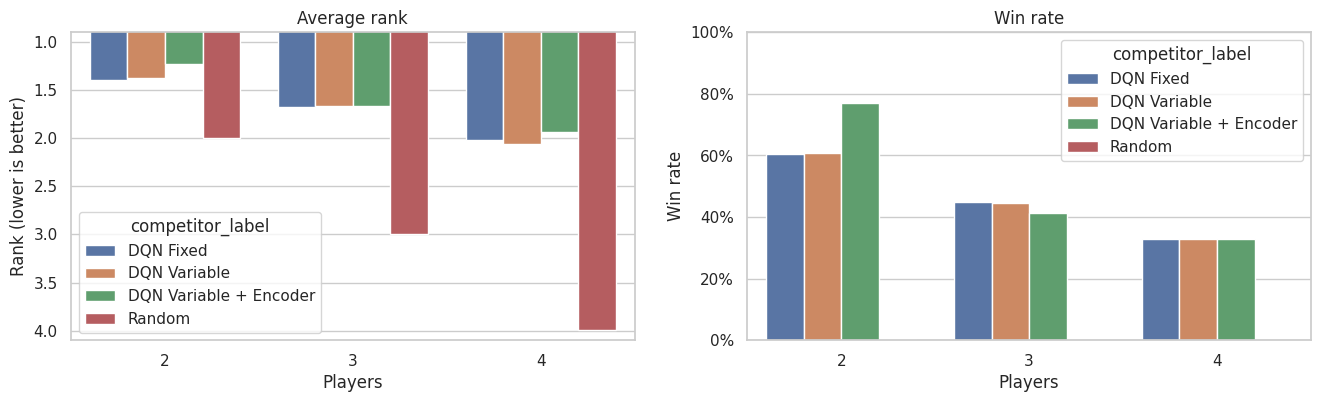

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

sns.barplot(
    data=overall,
    x="player_count",
    y="average_rank",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Average rank")
axes[0].set_xlabel("Players")
axes[0].set_ylabel("Rank (lower is better)")
axes[0].set_ylim(df["player_count"].max() + 0.1, 0.9)

sns.barplot(
    data=overall,
    x="player_count",
    y="raw_win_rate",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].set_title("Win rate")
axes[1].set_xlabel("Players")
axes[1].set_ylabel("Win rate")
axes[1].set_ylim(0, 1)
axes[1].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

## Matchup View

In [63]:
opponent_rows = []
for row in df.itertuples(index=False):
    for opponent_label, opponent_points in zip(row.opponent_labels, pipe_ints(row.opponent_points_all)):
        opponent_rows.append({
            "player_count": row.player_count,
            "competitor_label": row.competitor_label,
            "opponent_label": opponent_label,
            "head_to_head_win": row.points > opponent_points,
            "head_to_head_tie": row.points == opponent_points,
            "head_to_head_margin": row.points - opponent_points,
        })

opponent_df = pd.DataFrame(opponent_rows)
matchup_summary = (
    opponent_df.groupby(["player_count", "competitor_label", "opponent_label"])
      .agg(
          rows=("head_to_head_win", "size"),
          head_to_head_wins=("head_to_head_win", "sum"),
          head_to_head_ties=("head_to_head_tie", "sum"),
          head_to_head_win_rate=("head_to_head_win", "mean"),
          mean_head_to_head_margin=("head_to_head_margin", "mean"),
      )
      .reset_index()
)
matchup_summary.style.format({
    "head_to_head_win_rate": "{:.1%}",
    "mean_head_to_head_margin": "{:+.2f}",
})

,player_count,competitor_label,opponent_label,rows,head_to_head_wins,head_to_head_ties,head_to_head_win_rate,mean_head_to_head_margin
0,2,DQN Fixed,DQN Variable,100,47,5,47.0%,+1.16
1,2,DQN Fixed,DQN Variable + Encoder,100,30,4,30.0%,-2.67
2,2,DQN Fixed,Random,100,99,0,99.0%,+24.78
3,2,DQN Variable,DQN Fixed,100,48,5,48.0%,-1.16
4,2,DQN Variable,DQN Variable + Encoder,100,32,8,32.0%,-2.84
5,2,DQN Variable,Random,100,100,0,100.0%,+24.29
6,2,DQN Variable + Encoder,DQN Fixed,100,66,4,66.0%,+2.67
7,2,DQN Variable + Encoder,DQN Variable,100,60,8,60.0%,+2.84
8,2,DQN Variable + Encoder,Random,100,100,0,100.0%,+27.04
9,2,Random,DQN Fixed,100,1,0,1.0%,-24.78


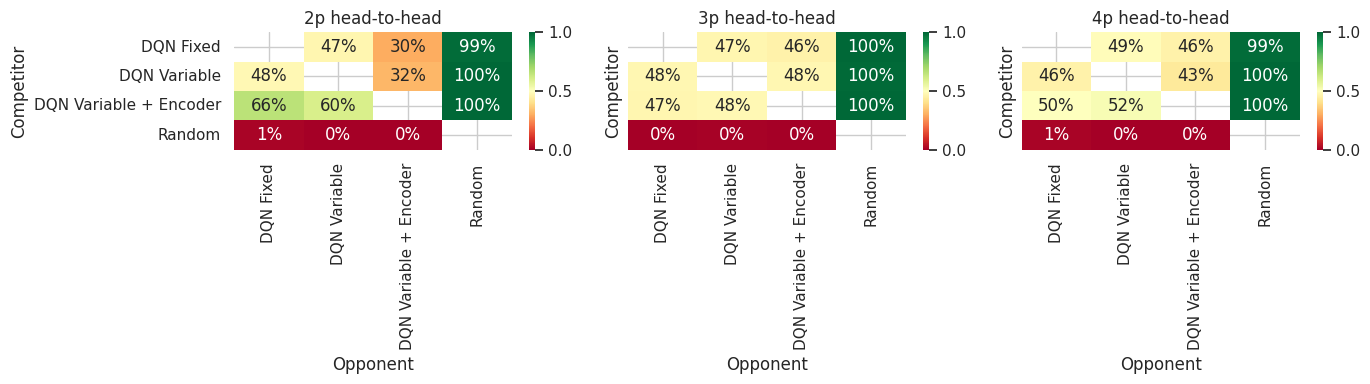

In [64]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, player_count in zip(axes, (2, 3, 4)):
    matrix = matchup_summary[matchup_summary["player_count"] == player_count].pivot(
        index="competitor_label", columns="opponent_label", values="head_to_head_win_rate"
    ).reindex(index=model_order, columns=model_order)
    sns.heatmap(matrix, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="RdYlGn", ax=ax)
    ax.set_title(f"{player_count}p head-to-head")
    ax.set_xlabel("Opponent")
    ax.set_ylabel("Competitor")
plt.tight_layout()

## Repetition Variance

In [65]:
repetition_results = (
    df.groupby(["player_count", "competitor_label", "repetition"])
      .agg(
          games=("match_id", "size"),
          average_rank=("average_rank", "mean"),
          raw_win_rate=("won", "mean"),
      )
      .reset_index()
)

repetition_variance = (
    repetition_results.groupby(["player_count", "competitor_label"])
      .agg(
          repetitions=("repetition", "nunique"),
          mean_average_rank=("average_rank", "mean"),
          average_rank_variance=("average_rank", "var"),
          mean_win_rate=("raw_win_rate", "mean"),
          win_rate_variance=("raw_win_rate", "var"),
      )
      .reset_index()
)
repetition_variance[["average_rank_variance", "win_rate_variance"]] = repetition_variance[
    ["average_rank_variance", "win_rate_variance"]
].fillna(0)
repetition_variance.style.format({
    "mean_average_rank": "{:.2f}",
    "average_rank_variance": "{:.4f}",
    "mean_win_rate": "{:.1%}",
    "win_rate_variance": "{:.4f}",
})


,player_count,competitor_label,repetitions,mean_average_rank,average_rank_variance,mean_win_rate,win_rate_variance
0,2,DQN Fixed,1,1.40,0.0000,60.3%,0.0000
1,2,DQN Variable,1,1.38,0.0000,60.7%,0.0000
2,2,DQN Variable + Encoder,1,1.23,0.0000,77.0%,0.0000
3,2,Random,1,2.00,0.0000,0.3%,0.0000
4,3,DQN Fixed,1,1.67,0.0000,45.0%,0.0000
5,3,DQN Variable,1,1.67,0.0000,44.7%,0.0000
6,3,DQN Variable + Encoder,1,1.66,0.0000,41.3%,0.0000
7,3,Random,1,3.00,0.0000,0.0%,0.0000
8,4,DQN Fixed,1,2.02,0.0000,33.0%,0.0000
9,4,DQN Variable,1,2.06,0.0000,33.0%,0.0000


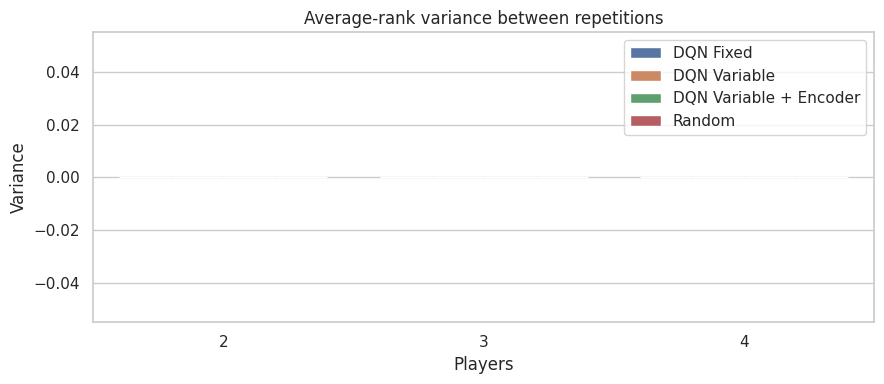

In [66]:
plt.figure(figsize=(9, 4))
sns.barplot(
    data=repetition_variance,
    x="player_count",
    y="average_rank_variance",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
)
plt.title("Average-rank variance between repetitions")
plt.xlabel("Players")
plt.ylabel("Variance")
plt.legend(title="")
plt.tight_layout()


## Seat Effects

In [67]:
seat_results = (
    df.groupby(["player_count", "competitor_label", "seat"])
      .agg(
          games=("match_id", "size"),
          average_rank=("average_rank", "mean"),
          raw_win_rate=("won", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
seat_results.style.format({
    "average_rank": "{:.2f}",
    "raw_win_rate": "{:.1%}",
    "mean_margin": "{:+.2f}",
})


,player_count,competitor_label,seat,games,average_rank,raw_win_rate,mean_margin
0,2,DQN Fixed,0,143,1.41,58.7%,+6.40
1,2,DQN Fixed,1,157,1.39,61.8%,+8.99
2,2,DQN Variable,0,150,1.39,59.3%,+6.27
3,2,DQN Variable,1,150,1.37,62.0%,+7.25
4,2,DQN Variable + Encoder,0,142,1.23,77.5%,+10.06
5,2,DQN Variable + Encoder,1,158,1.22,76.6%,+11.56
6,2,Random,0,165,1.99,0.6%,-25.72
7,2,Random,1,135,2.00,0.0%,-24.95
8,3,DQN Fixed,0,104,1.68,42.3%,+7.97
9,3,DQN Fixed,1,92,1.60,48.9%,+9.66


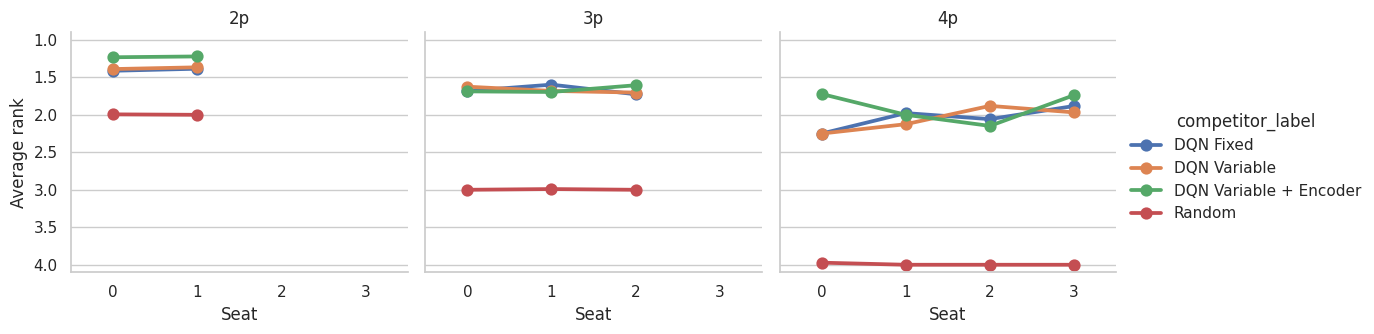

In [68]:
grid = sns.catplot(
    data=seat_results,
    kind="point",
    x="seat",
    y="average_rank",
    hue="competitor_label",
    hue_order=model_order,
    col="player_count",
    errorbar=None,
    height=3.5,
    aspect=1.1,
)
grid.set_axis_labels("Seat", "Average rank")
grid.set_titles("{col_name}p")
for ax in grid.axes.flat:
    ax.set_ylim(df["player_count"].max() + 0.1, 0.9)


## Training Metrics

In [69]:
metrics_candidates = [Path("results/league"), Path("../../results/league")]
metrics_root = next(path for path in metrics_candidates if path.exists())

checkpoint_aliases = {
    "fixed_2p": "DQN Fixed 2 Players",
    "fixed_3p": "DQN Fixed 3 Players",
    "fixed_4p": "DQN Fixed 4 Players",
    "variable_2_4": "DQN Variable",
    "variable_encoder_2_4": "DQN Variable + Encoder",
}

training_metrics = []
for model, alias in checkpoint_aliases.items():
    for metrics_path in sorted((metrics_root / model).glob("repetition_*/metrics.csv")):
        metrics = pd.read_csv(metrics_path)
        metrics["checkpoint"] = alias
        metrics["repetition"] = int(metrics_path.parent.name.removeprefix("repetition_"))
        training_metrics.append(metrics)

training_df = pd.concat(training_metrics, ignore_index=True)
training_df["loss_smoothed"] = training_df.groupby(["checkpoint", "repetition"])["loss"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)
training_df["return_smoothed"] = training_df.groupby(["checkpoint", "repetition"])["mean_episode_return"].transform(
    lambda x: x.rolling(100, min_periods=1).mean()
)

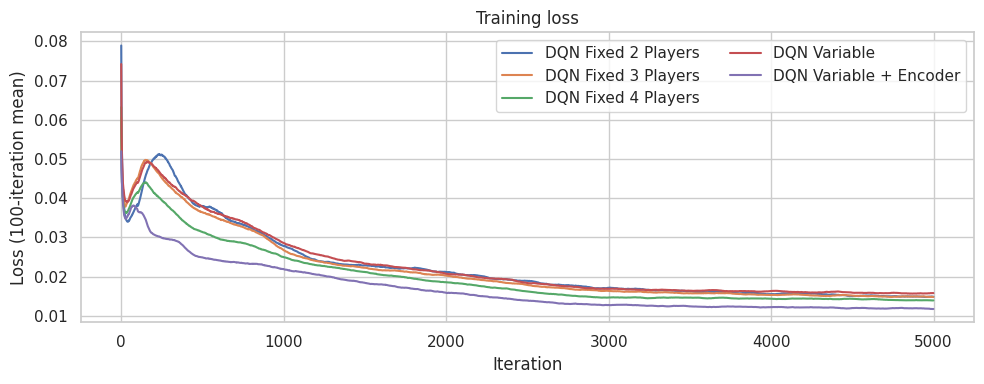

In [70]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=training_df, x="iteration", y="loss_smoothed", hue="checkpoint", errorbar=None)
plt.title("Training loss")
plt.xlabel("Iteration")
plt.ylabel("Loss (100-iteration mean)")
plt.legend(title="", ncol=2)
plt.tight_layout()

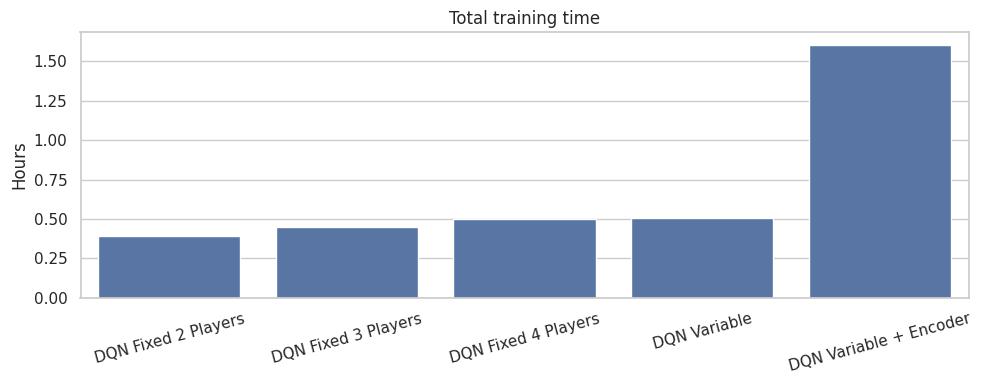

In [71]:
training_time = training_df.groupby(["checkpoint", "repetition"], as_index=False)["elapsed_seconds"].max()
training_time["hours"] = training_time["elapsed_seconds"] / 3600

plt.figure(figsize=(10, 4))
sns.barplot(data=training_time, x="checkpoint", y="hours", errorbar=None)
plt.title("Total training time")
plt.xlabel("")
plt.ylabel("Hours")
plt.xticks(rotation=15)
plt.tight_layout()

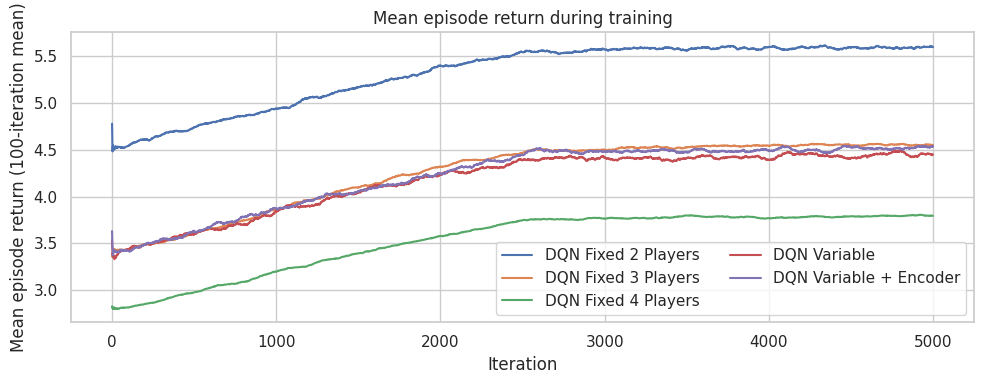

In [72]:
plt.figure(figsize=(10, 4))
sns.lineplot(data=training_df, x="iteration", y="return_smoothed", hue="checkpoint", errorbar=None)
plt.title("Mean episode return during training")
plt.xlabel("Iteration")
plt.ylabel("Mean episode return (100-iteration mean)")
plt.legend(title="", ncol=2)
plt.tight_layout()